# Индивидуальная работа 1
## Описательный, инференциальный и визуальный анализ данных

| | |
|---|---|
| **Набор данных** | Medical Cost Personal Dataset (`insurance.csv`) |
| **Источник** | [Kaggle — mirichoi0218/insurance](https://www.kaggle.com/datasets/mirichoi0218/insurance) |
| **Студент** | Mihailov Piotr I2302se


---
## I. Введение

### 1.1 Цель анализа

Данная работа посвящена статистическому анализу факторов, влияющих на страховые медицинские расходы для выборки из **1338 застрахованных** лиц в США. Набор данных *Medical Cost Personal Dataset* находится в открытом доступе на платформе Kaggle.

Анализ направлен на изучение структуры распределения страховых расходов, оценку параметров генеральной совокупности и проверку статистических гипотез о влиянии демографических и поведенческих факторов на стоимость страховки.

### 1.2 Статистические задачи

1. Описать распределение числовых переменных (`age`, `bmi`, `charges`) — описательные статистики и графики.
2. Построить 95%-е доверительные интервалы для средних расходов, доли курильщиков и стандартного отклонения.
3. Проверить гипотезу: расходы курильщиков значимо выше расходов некурящих (t-тест Уэлча).
4. Проверить связь между полом и статусом курильщика (критерий χ²).
5. Сравнить средние расходы по 4 регионам США (однофакторный ANOVA + пост-хок Бонферрони).

### 1.3 Описание набора данных

| Переменная | Тип | Описание |
|:-----------|:----|:---------|
| `age` | Числовая (целая) | Возраст застрахованного, лет |
| `sex` | Категориальная (бинарная) | Пол: `male` / `female` |
| `bmi` | Числовая (непрерывная) | Индекс массы тела, кг/м² |
| `children` | Числовая (целая) | Количество детей в страховке |
| `smoker` | Категориальная (бинарная) | Статус курильщика: `yes` / `no` |
| `region` | Категориальная (4 класса) | Регион США |
| `charges` | Числовая (непрерывная) | **Страховые расходы, долл. США** — целевая переменная |

> **1338 наблюдений · 7 переменных · 0 пропущенных значений**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, shapiro, levene, ttest_ind
from itertools import combinations
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('insurance.csv')
print(f'Наблюдений:            {df.shape[0]}')
print(f'Переменных:            {df.shape[1]}')
print(f'Пропущенных значений:  {df.isnull().sum().sum()}')
df.head()

Наблюдений:            1338
Переменных:            7
Пропущенных значений:  0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
## II. Описательный анализ и визуализация данных

### 2.1 Описательные статистики числовых переменных

In [22]:
num_vars = ['age', 'bmi', 'children', 'charges']
desc = df[num_vars].agg(['mean', 'median', 'std', 'min', 'max']).T
desc.columns = ['Среднее', 'Медиана', 'Ст. откл.', 'Минимум', 'Максимум']
desc.round(2)

,Среднее,Медиана,Ст. откл.,Минимум,Максимум
age,39.21,39.00,14.05,18.00,64.00
bmi,30.66,30.40,6.10,15.96,53.13
children,1.09,1.00,1.21,0.00,5.00
charges,13270.42,9382.03,12110.01,1121.87,63770.43


> **Интерпретация:**  
> Средний возраст — **39.2 года** (диапазон 18–64). Среднее ИМТ = **30.7 кг/м²** — граница ожирения 1-й степени (≥ 30). Переменная `charges` демонстрирует **правостороннюю асимметрию**: среднее (**13 270 долл.**) значительно превышает медиану (**9 382 долл.**) — разрыв ~3 888 долл. указывает на группу с экстремально высокими расходами.

### 2.2 Частоты и доли категориальных переменных

In [42]:
for col in ['sex', 'smoker', 'region']:
    counts = df[col].value_counts()
    pct    = df[col].value_counts(normalize=True).mul(100).round(1)
    result = pd.DataFrame({'Кол-во': counts, 'Доля (%)': pct})
    print(f'\n── {col} ──')
    print(result.to_string())


── sex ──
        Кол-во  Доля (%)
sex                     
male       676      50.5
female     662      49.5

── smoker ──
        Кол-во  Доля (%)
smoker                  
no        1064      79.5
yes        274      20.5

── region ──
           Кол-во  Доля (%)
region                     
southeast     364      27.2
southwest     325      24.3
northwest     325      24.3
northeast     324      24.2


> **Интерпретация:**  
> Выборка сбалансирована по полу (50.5% мужчин). Курящие составляют **20.5%** (274 из 1338). Распределение по регионам равномерное — `southeast` незначительно преобладает (27.2%).

### 2.3 Гистограммы числовых переменных

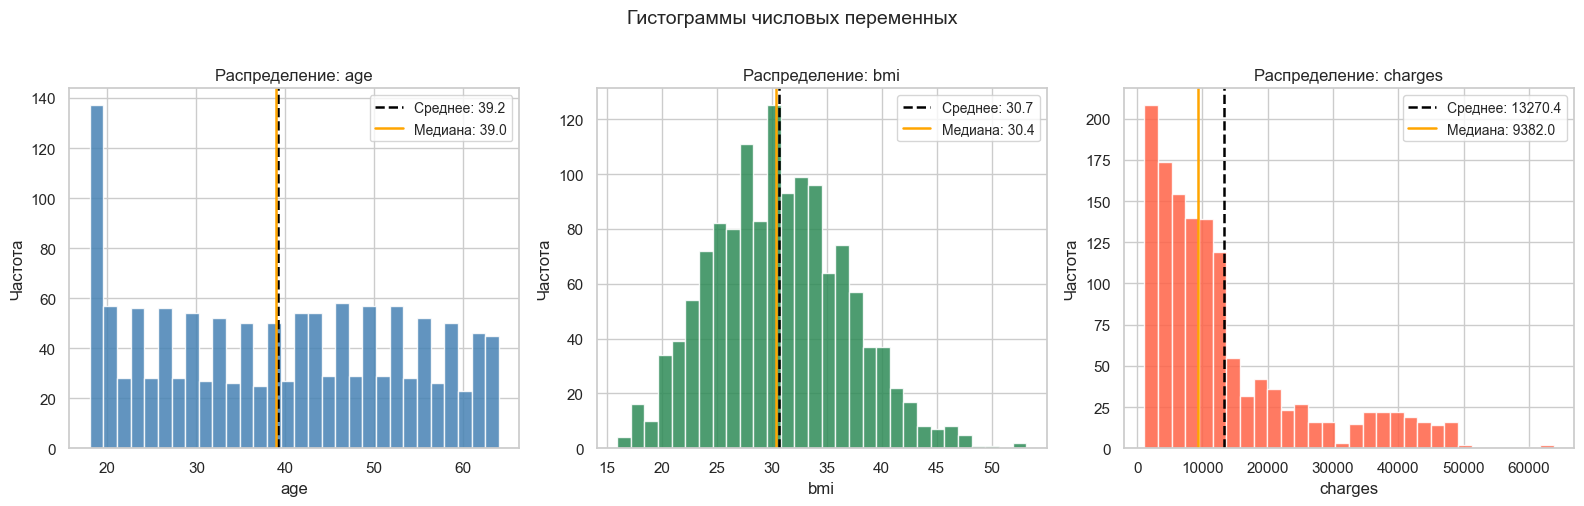

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(axes,
                           ['age', 'bmi', 'charges'],
                           ['steelblue', 'seagreen', 'tomato']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black',  ls='--', lw=1.8,
               label=f'Среднее: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', ls='-',  lw=1.8,
               label=f'Медиана: {df[col].median():.1f}')
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
    ax.legend(fontsize=10)
plt.suptitle('Гистограммы числовых переменных', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

На гистограммах видно распределение трёх числовых переменных. Возраст — равномерное распределение, среднее совпадает с медианой. ИМТ — форма колокола, тоже симметричное. А вот расходы — принципиально другая картина: высокий пик слева и длинный хвост вправо. Оранжевая линия медианы стоит заметно левее чёрной линии среднего. Это правосторонняя асимметрия — небольшая дорогая группа тянет среднее вверх.


### 2.4 Боксплоты страховых расходов по группам

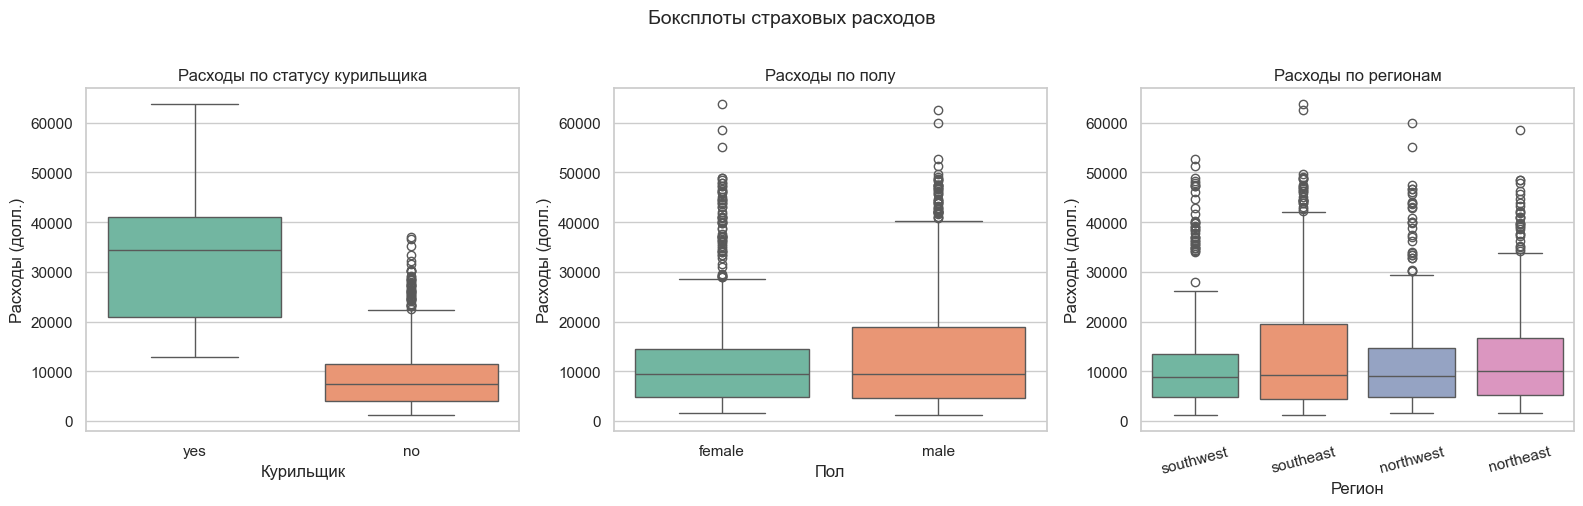

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='smoker', y='charges', hue='smoker',
            ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Расходы по статусу курильщика')
axes[0].set_xlabel('Курильщик')
axes[0].set_ylabel('Расходы (долл.)')

sns.boxplot(data=df, x='sex', y='charges', hue='sex',
            ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Расходы по полу')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Расходы (долл.)')

sns.boxplot(data=df, x='region', y='charges', hue='region',
            ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('Расходы по регионам')
axes[2].set_xlabel('Регион')
axes[2].set_ylabel('Расходы (долл.)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Боксплоты страховых расходов', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

На трёх боксплотах я сравниваю расходы между группами. Первый — самый важный. Ящик курящих стоит намного выше ящика некурящих — медиана 35 000 против 7 500, разница в 4.5 раза. Ящики вообще не пересекаются. По полу — почти одинаково, пол не влияет. По регионам — медианы близкие, southeast чуть выше остальных


### 2.5 Столбчатые диаграммы категориальных переменных

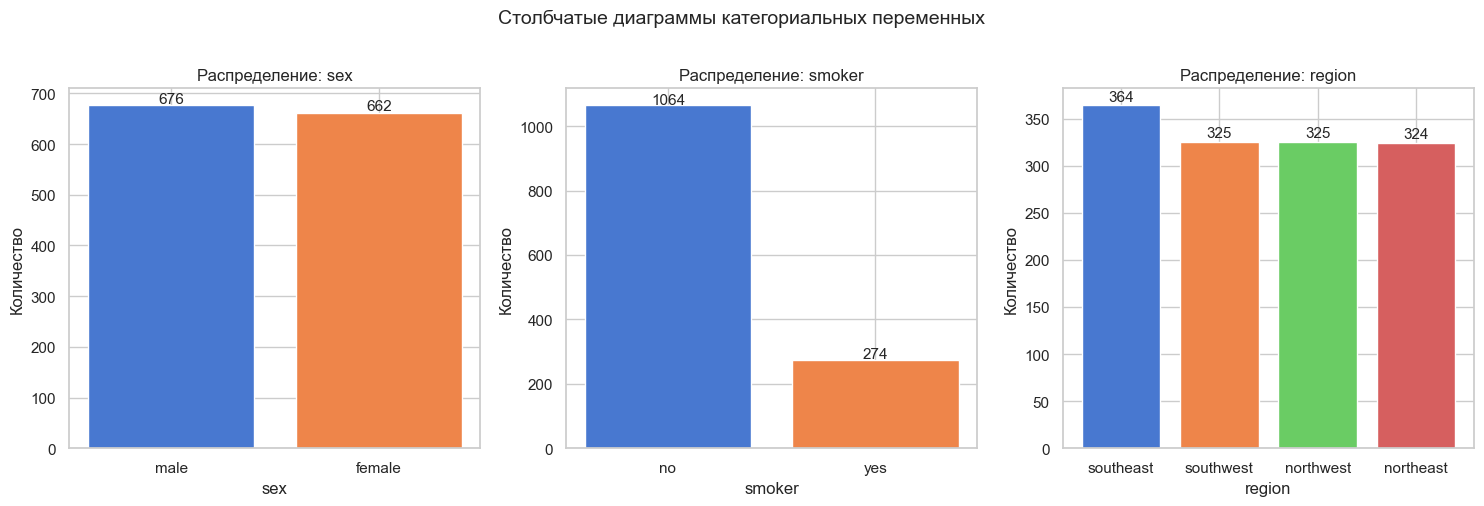

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['sex', 'smoker', 'region']):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(counts)),
                  edgecolor='white')
    ax.set_title(f'Распределение: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 5, str(v), ha='center', fontsize=11)
plt.suptitle('Столбчатые диаграммы категориальных переменных', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Интерпретация:**  
> Диаграммы подтверждают сбалансированность выборки по полу и регионам. Некурящих (1064) в **3.9 раза** больше, чем курящих (274).

### 2.6 Эмпирическая функция распределения (ECDF)

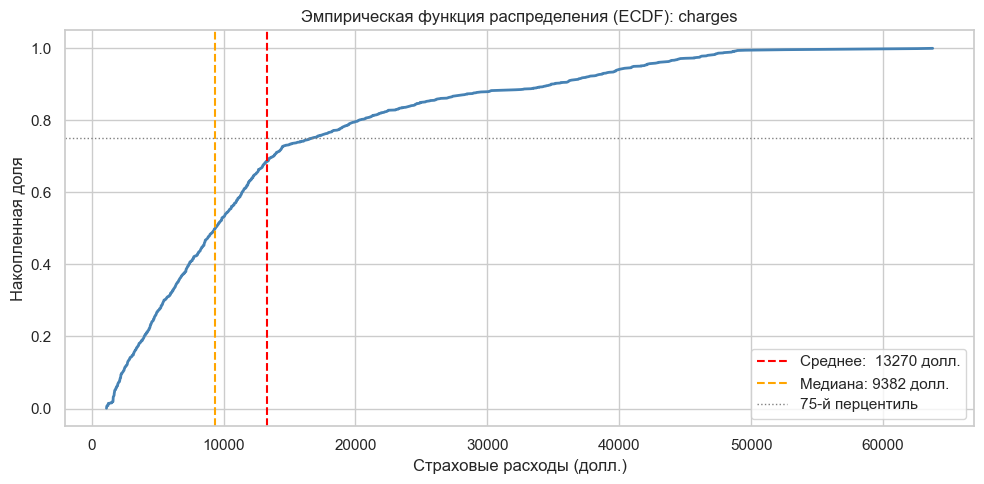

In [64]:
x = np.sort(df['charges'])
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='steelblue', lw=2)
plt.axvline(df['charges'].mean(),   color='red',    ls='--',
            label=f'Среднее:  {df["charges"].mean():.0f} долл.')
plt.axvline(df['charges'].median(), color='orange', ls='--',
            label=f'Медиана: {df["charges"].median():.0f} долл.')
plt.axhline(0.75, color='grey', ls=':', lw=1, label='75-й перцентиль')
plt.xlabel('Страховые расходы (долл.)')
plt.ylabel('Накопленная доля')
plt.title('Эмпирическая функция распределения (ECDF): charges')
plt.legend()
plt.tight_layout()
plt.show()

На графике ECDF видно накопленное распределение расходов. Оранжевая линия — медиана 9 382, кривая здесь на уровне 0.50 — половина людей платит меньше. Красная линия — среднее 13 270, кривая уже на 0.70 — значит 70% людей платят меньше среднего. Это ещё раз подтверждает асимметрию: среднее завышено из-за небольшой дорогой группы. Кривая крутая слева и пологая справа — 94% людей платят меньше 30 000, и только 6% выше.


### 2.7 Диаграммы рассеяния: числовые предикторы vs расходы

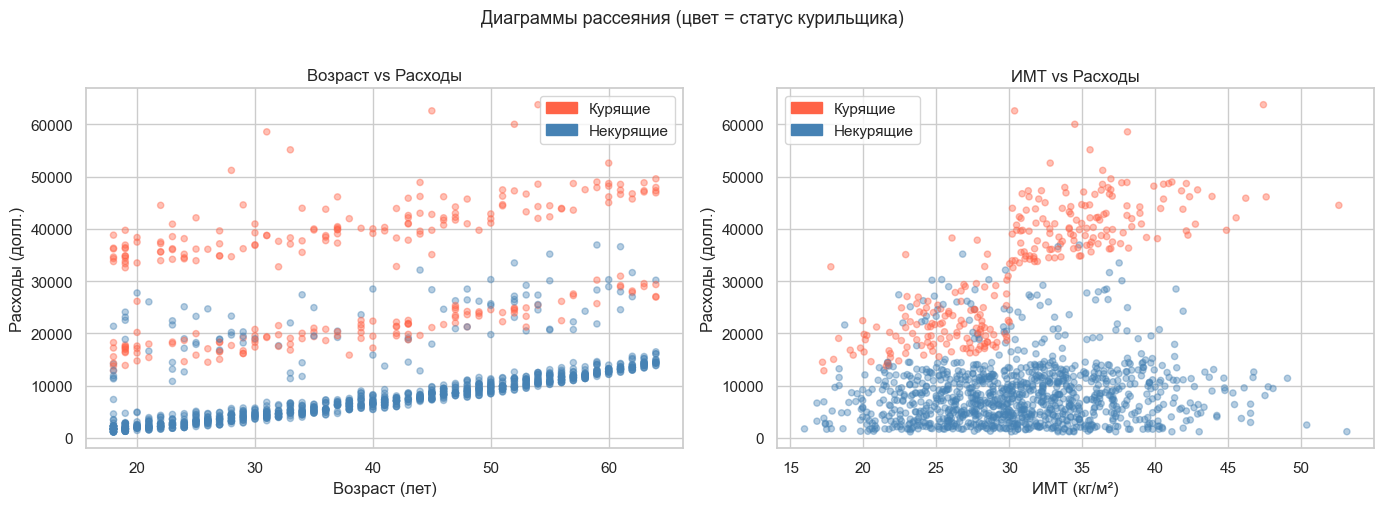

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})
legend_handles = [
    Patch(color='tomato',    label='Курящие'),
    Patch(color='steelblue', label='Некурящие')
]

axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.4, s=20)
axes[0].set_title('Возраст vs Расходы')
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Расходы (долл.)')
axes[0].legend(handles=legend_handles)

axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.4, s=20)
axes[1].set_title('ИМТ vs Расходы')
axes[1].set_xlabel('ИМТ (кг/м²)')
axes[1].set_ylabel('Расходы (долл.)')
axes[1].legend(handles=legend_handles)

plt.suptitle('Диаграммы рассеяния (цвет = статус курильщика)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

На диаграммах рассеяния каждая точка — один человек, красные курят, синие нет. На обоих графиках одна и та же картина: красные точки образуют отдельный верхний слой, синие внизу. Они практически не перемешиваются. На графике с ИМТ особенно видно: курящие с ИМТ выше 30 резко уходят вверх — это синергетический эффект ожирения и курения, максимальные расходы во всей выборке


---
## III. Оценка параметров и доверительные интервалы

**Доверительный интервал (ДИ) уровня 95%** — диапазон значений, покрывающий истинный параметр генеральной совокупности с вероятностью 0.95 при многократном повторении выборки.

| Параметр | Формула | Распределение |
|:---------|:--------|:--------------|
| Среднее | $\bar{x} \pm t_{\alpha/2,\,n-1} \cdot \frac{s}{\sqrt{n}}$ | t-Стьюдента |
| Пропорция | $\hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$ | Нормальное |
| Ст. отклонение | $\left[\sqrt{\frac{(n-1)s^2}{\chi^2_{1-\alpha/2}}};\; \sqrt{\frac{(n-1)s^2}{\chi^2_{\alpha/2}}}\right]$ | χ² |

### 3.1 Доверительный интвервал для средних страховых расходов

In [66]:
charges = df['charges']
n       = len(charges)
mean_c  = charges.mean()
se_c    = stats.sem(charges)        # SE = s / sqrt(n)
ci_c    = stats.t.interval(0.95, df=n-1, loc=mean_c, scale=se_c)

print(f'n  = {n}')
print(f'x̄  = {mean_c:.2f} долл.')
print(f'SE = {se_c:.2f}')
print(f'95% ДИ: [{ci_c[0]:.2f} ; {ci_c[1]:.2f}] долл.')

n  = 1338
x̄  = 13270.42 долл.
SE = 331.07
95% ДИ: [12620.95 ; 13919.89] долл.


> **Интерпретация:**  
> С вероятностью 95% среднее значение страховых расходов в генеральной совокупности находится в диапазоне **[12 621 ; 13 920] долл.** Ширина интервала (~1 299 долл.) мала благодаря большому n = 1338.

### 3.2 Доверительный интервал для доли курильщиков

In [67]:
n_smokers = (df['smoker'] == 'yes').sum()
p_hat     = n_smokers / n
se_p      = np.sqrt(p_hat * (1 - p_hat) / n)
z95       = stats.norm.ppf(0.975)   # z = 1.96
ci_p      = (p_hat - z95 * se_p, p_hat + z95 * se_p)

print(f'Число курящих:  {n_smokers}')
print(f'p̂  = {p_hat:.4f}  ({p_hat*100:.1f}%)')
print(f'SE = {se_p:.4f}')
print(f'95% ДИ: [{ci_p[0]:.4f} ; {ci_p[1]:.4f}]')
print(f'        [{ci_p[0]*100:.1f}% ; {ci_p[1]*100:.1f}%]')
print(f'n·p̂ = {n*p_hat:.0f} >> 5  ✓  (условие нормального приближения)')

Число курящих:  274
p̂  = 0.2048  (20.5%)
SE = 0.0110
95% ДИ: [0.1832 ; 0.2264]
        [18.3% ; 22.6%]
n·p̂ = 274 >> 5  ✓  (условие нормального приближения)


> **Интерпретация:**  
> Доля курильщиков в выборке — **20.5%**. С вероятностью 95% истинная доля курящих находится в диапазоне **[18.3% ; 22.6%]**.

### 3.3 Доверительный интвервал для стандартного отклонения расходов

In [68]:
s        = charges.std(ddof=1)
chi2_lo  = stats.chi2.ppf(0.025, df=n-1)
chi2_hi  = stats.chi2.ppf(0.975, df=n-1)
ci_s_lo  = np.sqrt((n-1) * s**2 / chi2_hi)
ci_s_hi  = np.sqrt((n-1) * s**2 / chi2_lo)

print(f's  = {s:.2f} долл.')
print(f'χ²₀.₀₂₅ = {chi2_lo:.2f},   χ²₀.₉₇₅ = {chi2_hi:.2f}')
print(f'95% ДИ для σ: [{ci_s_lo:.2f} ; {ci_s_hi:.2f}] долл.')

s  = 12110.01 долл.
χ²₀.₀₂₅ = 1237.56,   χ²₀.₉₇₅ = 1440.23
95% ДИ для σ: [11667.94 ; 12587.16] долл.


### 3.4 Визуализация доверительных интервалов

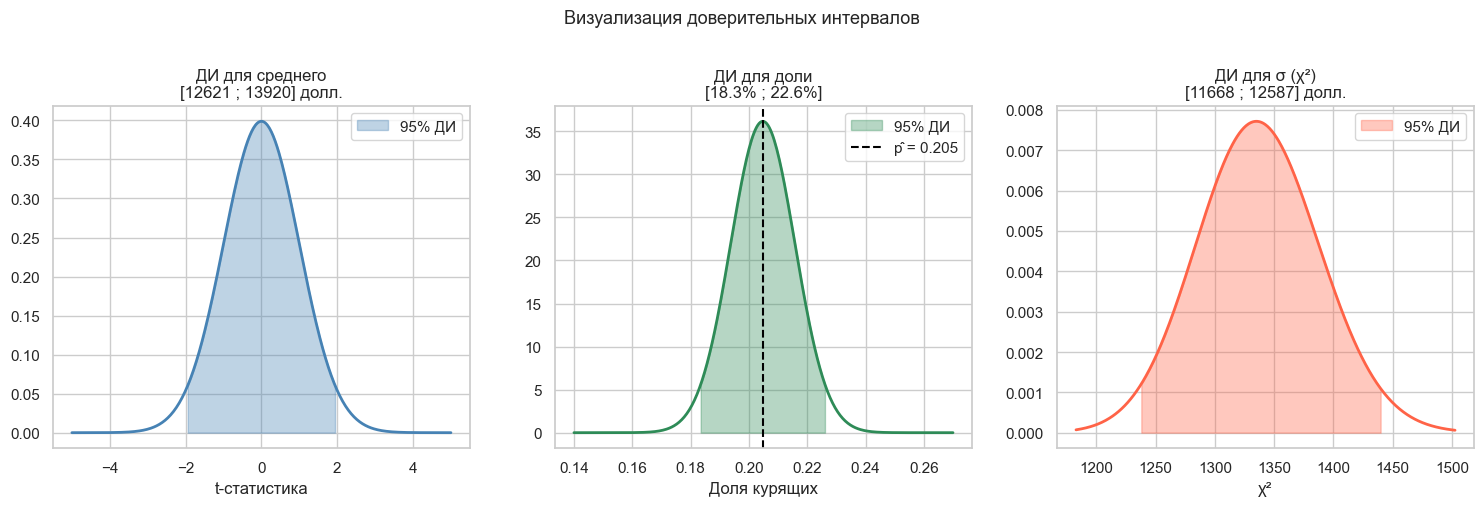

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─── ДИ для среднего (t-распределение) ───
x_t  = np.linspace(-5, 5, 400)
y_t  = stats.t.pdf(x_t, df=n-1)
t_lo = (ci_c[0] - mean_c) / se_c
t_hi = (ci_c[1] - mean_c) / se_c
axes[0].plot(x_t, y_t, 'steelblue', lw=2)
axes[0].fill_between(x_t, y_t,
    where=(x_t >= t_lo) & (x_t <= t_hi),
    alpha=0.35, color='steelblue', label='95% ДИ')
axes[0].set_title(f'ДИ для среднего\n[{ci_c[0]:.0f} ; {ci_c[1]:.0f}] долл.')
axes[0].set_xlabel('t-статистика')
axes[0].legend()

# ─── ДИ для доли (нормальное) ───
p_range = np.linspace(0.14, 0.27, 300)
y_p     = stats.norm.pdf(p_range, p_hat, se_p)
axes[1].plot(p_range, y_p, 'seagreen', lw=2)
axes[1].fill_between(p_range, y_p,
    where=(p_range >= ci_p[0]) & (p_range <= ci_p[1]),
    alpha=0.35, color='seagreen', label='95% ДИ')
axes[1].axvline(p_hat, color='black', ls='--', label=f'p̂ = {p_hat:.3f}')
axes[1].set_title(f'ДИ для доли\n[{ci_p[0]*100:.1f}% ; {ci_p[1]*100:.1f}%]')
axes[1].set_xlabel('Доля курящих')
axes[1].legend()

# ─── ДИ для σ (χ²-распределение) ───
x_c = np.linspace(stats.chi2.ppf(0.001, df=n-1),
                   stats.chi2.ppf(0.999, df=n-1), 500)
y_c = stats.chi2.pdf(x_c, df=n-1)
axes[2].plot(x_c, y_c, 'tomato', lw=2)
axes[2].fill_between(x_c, y_c,
    where=(x_c >= chi2_lo) & (x_c <= chi2_hi),
    alpha=0.35, color='tomato', label='95% ДИ')
axes[2].set_title(f'ДИ для σ (χ²)\n[{ci_s_lo:.0f} ; {ci_s_hi:.0f}] долл.')
axes[2].set_xlabel('χ²')
axes[2].legend()

plt.suptitle('Визуализация доверительных интервалов', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

На трёх графиках я визуализировал доверительные интервалы. На каждом — кривая распределения и закрашенная область. Закрашенное — это 95% доверительная зона, незакрашенные хвосты — оставшиеся 5%. Левый график для среднего — интервал 12 621 до 13 920 долларов. Средний для доли курящих — от 18.3% до 22.6%. Правый для разброса расходов — от 11 668 до 12 587. Правый график несимметричный потому что хи-квадрат распределение несимметрично по своей природе


---
## IV. Проверка гипотез — t-тест Уэлча

Применяется **двухвыборочный независимый t-тест Уэлча** — не предполагает равенства дисперсий групп.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

| | |
|---|---|
| **H₀** | μ_курящие = μ_некурящие |
| **H₁** | μ_курящие ≠ μ_некурящие |
| **α** | 0.05 |

In [70]:
smokers     = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

print(f'{"Группа":<12} {"n":>5}  {"Среднее":>12}  {"Медиана":>12}  {"Ст. откл.":>12}')
print('-' * 58)
print(f'{"Курящие":<12} {len(smokers):>5}  {smokers.mean():>12.2f}  '
      f'{smokers.median():>12.2f}  {smokers.std():>12.2f}')
print(f'{"Некурящие":<12} {len(non_smokers):>5}  {non_smokers.mean():>12.2f}  '
      f'{non_smokers.median():>12.2f}  {non_smokers.std():>12.2f}')

t_stat, p_val = ttest_ind(smokers, non_smokers, equal_var=False)

print(f'\nt-статистика:  {t_stat:.4f}')
print(f'p-значение:    {p_val:.2e}')
print(f'\nВывод: {"Отвергаем H₀" if p_val < 0.05 else "Не отвергаем H₀"}  (α = 0.05)')

Группа           n       Среднее       Медиана     Ст. откл.
----------------------------------------------------------
Курящие        274      32050.23      34456.35      11541.55
Некурящие     1064       8434.27       7345.41       5993.78

t-статистика:  32.7519
p-значение:    5.89e-103

Вывод: Отвергаем H₀  (α = 0.05)


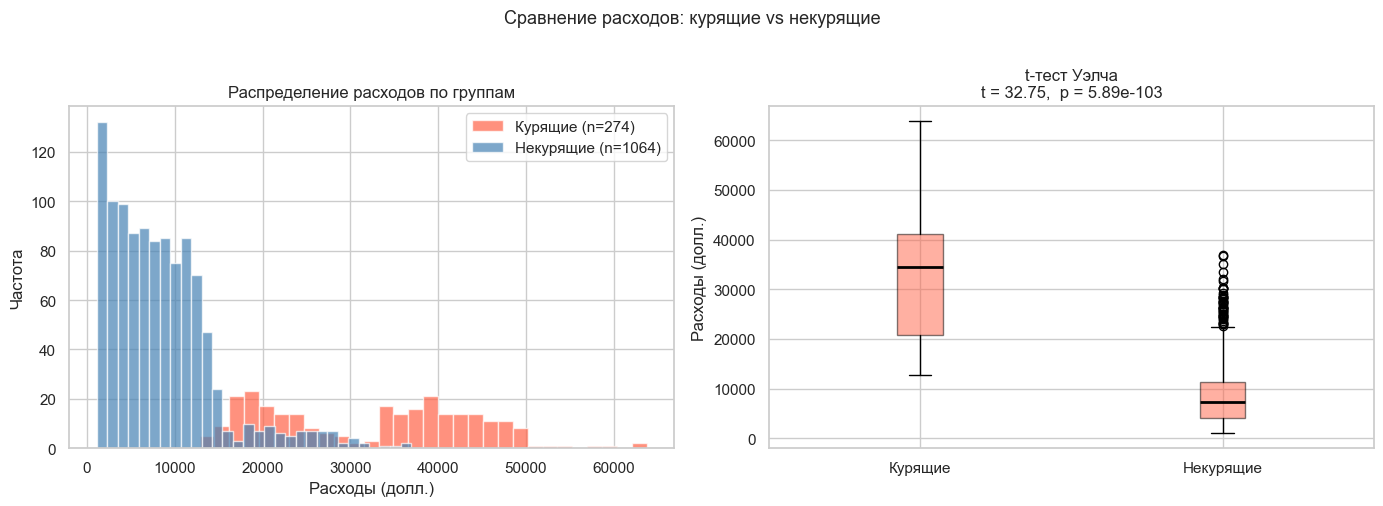

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(smokers, bins=30, alpha=0.7, color='tomato',
             label=f'Курящие (n={len(smokers)})', edgecolor='white')
axes[0].hist(non_smokers, bins=30, alpha=0.7, color='steelblue',
             label=f'Некурящие (n={len(non_smokers)})', edgecolor='white')
axes[0].set_title('Распределение расходов по группам')
axes[0].set_xlabel('Расходы (долл.)')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].boxplot([smokers, non_smokers],
                tick_labels=['Курящие', 'Некурящие'],
                patch_artist=True,
                boxprops=dict(facecolor='tomato', alpha=0.5),
                medianprops=dict(color='black', lw=2))
axes[1].set_title(f't-тест Уэлча\nt = {t_stat:.2f},  p = {p_val:.2e}')
axes[1].set_ylabel('Расходы (долл.)')

plt.suptitle('Сравнение расходов: курящие vs некурящие', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

На левой гистограмме видно: синие некурящие сосредоточены в зоне до 15 000 долларов, красные курящие — в зоне 15 000–50 000. Группы почти не перекрываются. На правом боксплоте в заголовке сразу виден результат теста: t равно 32.75, p равно 5.89 на 10 в минус 103-й степени. Ящики двух групп вообще не пересекаются — даже нижняя граница ящика курящих выше верхней границы ящика некурящих. Нулевая гипотеза отвергается.

---
## V. Тесты для категориальных переменных — критерий χ²

Критерий χ² Пирсона для таблиц сопряжённости:

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad E_{ij} = \frac{R_i \cdot C_j}{n}$$

| | |
|---|---|
| **H₀** | Пол и статус курильщика независимы |
| **H₁** | Между полом и статусом курильщика есть зависимость |
| **α** | 0.05 |

In [72]:
ct_full = pd.crosstab(df['sex'], df['smoker'],
                       rownames=['Пол'], colnames=['Курильщик'],
                       margins=True, margins_name='Итого')
print('Таблица сопряжённости:')
print(ct_full.to_string())

ct = pd.crosstab(df['sex'], df['smoker'])
chi2_stat, p_chi, dof, expected = chi2_contingency(ct)

exp_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print('\nОжидаемые частоты (при H₀):')
print(exp_df.round(2).to_string())
print(f'\nВсе E_ij > 5: {(exp_df > 5).all().all()}  ✓')
print(f'\nχ²-статистика:   {chi2_stat:.4f}')
print(f'Степени свободы: {dof}')
print(f'p-значение:      {p_chi:.4f}')
print(f'\nВывод: {"Отвергаем H₀" if p_chi < 0.05 else "Не отвергаем H₀"}  (α = 0.05)')

Таблица сопряжённости:
Курильщик    no  yes  Итого
Пол                        
female      547  115    662
male        517  159    676
Итого      1064  274   1338

Ожидаемые частоты (при H₀):
smoker      no     yes
sex                   
female  526.43  135.57
male    537.57  138.43

Все E_ij > 5: True  ✓

χ²-статистика:   7.3929
Степени свободы: 1
p-значение:      0.0065

Вывод: Отвергаем H₀  (α = 0.05)


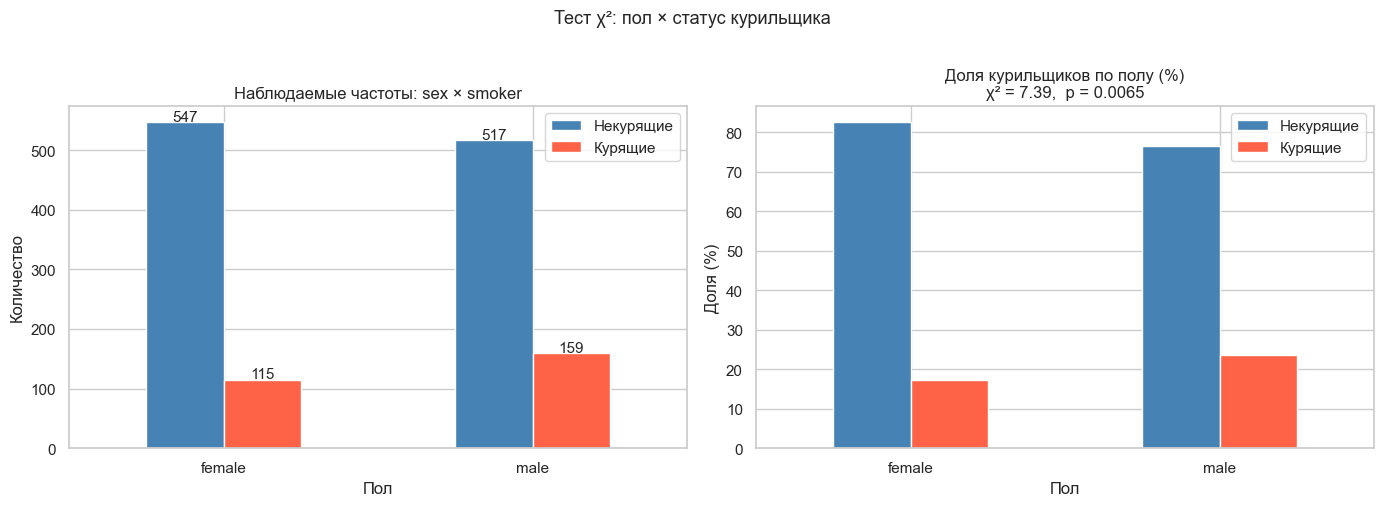

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct.plot(kind='bar', ax=axes[0],
        color=['steelblue', 'tomato'], edgecolor='white', rot=0)
axes[0].set_title('Наблюдаемые частоты: sex × smoker')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество')
axes[0].legend(['Некурящие', 'Курящие'])
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height() + 2),
        ha='center', fontsize=11)

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1],
            color=['steelblue', 'tomato'], edgecolor='white', rot=0)
axes[1].set_title(f'Доля курильщиков по полу (%)\nχ² = {chi2_stat:.2f},  p = {p_chi:.4f}')
axes[1].set_xlabel('Пол')
axes[1].set_ylabel('Доля (%)')
axes[1].legend(['Некурящие', 'Курящие'])

plt.suptitle('Тест χ²: пол × статус курильщика', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

На левом графике — реальные числа: среди женщин курят 115 человек, среди мужчин 159. На правом — те же данные в процентах: женщины 17.4%, мужчины 23.5%. В заголовке виден результат теста: хи-квадрат 7.39, p равно 0.0065. Это меньше 0.05 — нулевая гипотеза отвергается. Мужчины курят чаще, и это статистически значимо


---
## VI. Дисперсионный анализ — ANOVA

$$F = \frac{\text{MS}_{\text{между}}}{\text{MS}_{\text{внутри}}} = \frac{\text{SS}_{\text{между}} / (k-1)}{\text{SS}_{\text{внутри}} / (n-k)}$$

| | |
|---|---|
| **H₀** | μ_sw = μ_se = μ_nw = μ_ne |
| **H₁** | Хотя бы одно среднее значимо отличается |
| **α** | 0.05 |

Предпосылки: **нормальность** (тест Шапиро–Уилка) · **однородность дисперсий** (тест Ливиня)

In [74]:
regions = ['southwest', 'southeast', 'northwest', 'northeast']
groups  = [df[df['region'] == r]['charges'].values for r in regions]

print(f'{"Регион":<12}  {"n":>4}  {"Среднее":>10}  {"Медиана":>10}  {"Ст.откл.":>10}')
print('-' * 54)
for r, g in zip(regions, groups):
    print(f'{r:<12}  {len(g):4d}  {g.mean():10.2f}  '
          f'{np.median(g):10.2f}  {g.std():10.2f}')

Регион           n     Среднее     Медиана    Ст.откл.
------------------------------------------------------
southwest      325    12346.94     8798.59    11539.39
southeast      364    14735.41     9294.13    13951.89
northwest      325    12417.58     8965.80    11055.23
northeast      324    13406.38    10057.65    11238.42


In [75]:
# Предпосылка 1: нормальность (Шапиро–Уилк)
print('Тест Шапиро–Уилка (нормальность):')
for r, g in zip(regions, groups):
    w, p = shapiro(g[:200])
    verdict = 'норм.' if p > 0.05 else 'не норм.'
    print(f'  {r:<12}  W={w:.4f},  p={p:.4f}  →  {verdict}')

# Предпосылка 2: однородность дисперсий (Ливинь)
lev_w, lev_p = levene(*groups)
print(f'\nТест Ливиня:')
print(f'  W={lev_w:.4f},  p={lev_p:.4f}  →  '
      f'{"однородны" if lev_p > 0.05 else "неоднородны"}')

Тест Шапиро–Уилка (нормальность):
  southwest     W=0.7874,  p=0.0000  →  не норм.
  southeast     W=0.8316,  p=0.0000  →  не норм.
  northwest     W=0.7987,  p=0.0000  →  не норм.
  northeast     W=0.8109,  p=0.0000  →  не норм.

Тест Ливиня:
  W=5.5600,  p=0.0009  →  неоднородны


> **Комментарий:**  При n > 30 в каждой группе ANOVA устойчива к нарушению нормальности (ЦПТ). Неоднородность дисперсий учтена в пост-хок тестировании через t-тест Уэлча (equal_var=False).

In [76]:
f_stat_a, p_anova = f_oneway(*groups)

print('=== Однофакторный ANOVA: charges ~ region ===')
print(f'F-статистика:  {f_stat_a:.4f}')
print(f'p-значение:    {p_anova:.4f}')
print(f'\nВывод: {"Отвергаем H₀" if p_anova < 0.05 else "Не отвергаем H₀"}  (α = 0.05)')

=== Однофакторный ANOVA: charges ~ region ===
F-статистика:  2.9696
p-значение:    0.0309

Вывод: Отвергаем H₀  (α = 0.05)


In [77]:
pairs   = list(combinations(range(4), 2))
alpha_b = 0.05 / len(pairs)   # 0.05 / 6 = 0.0083

print(f'Пост-хок Бонферрони (α_скорр = {alpha_b:.4f}):\n')
print(f'{"Пара":<34} {"t":>8}  {"p":>10}  {"Значимо":>8}')
print('-' * 65)
for i, j in pairs:
    t, p = ttest_ind(groups[i], groups[j], equal_var=False)
    sig  = 'Да  *' if p < alpha_b else 'Нет'
    print(f'{regions[i]:<15} vs {regions[j]:<15} {t:8.3f}  {p:10.4f}  {sig:>8}')

Пост-хок Бонферрони (α_скорр = 0.0083):

Пара                                      t           p   Значимо
-----------------------------------------------------------------
southwest       vs southeast         -2.454      0.0144       Нет
southwest       vs northwest         -0.080      0.9366       Нет
southwest       vs northeast         -1.183      0.2372       Нет
southeast       vs northwest          2.425      0.0156       Нет
southeast       vs northeast          1.380      0.1680       Нет
northwest       vs northeast         -1.128      0.2597       Нет


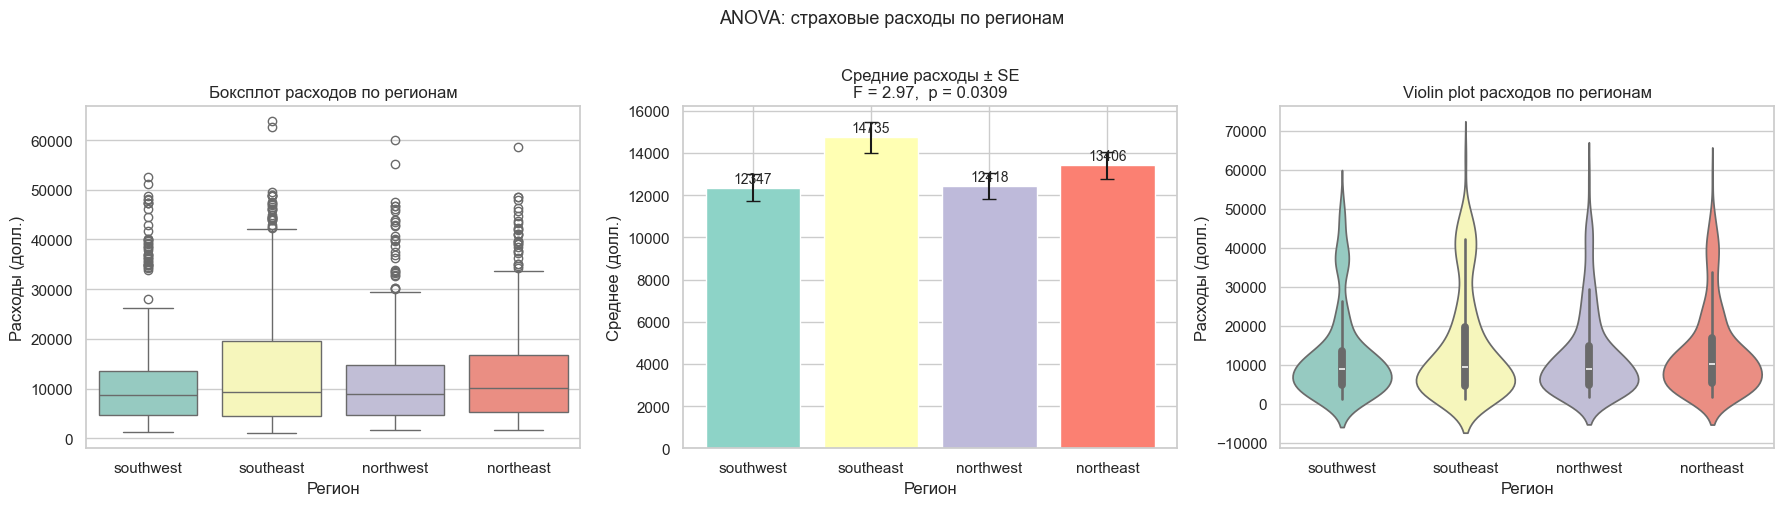

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='region', y='charges', hue='region',
            ax=axes[0], palette='Set3', legend=False)
axes[0].set_title('Боксплот расходов по регионам')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Расходы (долл.)')

means_r = [g.mean() for g in groups]
sems_r  = [g.std() / np.sqrt(len(g)) for g in groups]
bars = axes[1].bar(regions, means_r, yerr=sems_r,
                   color=sns.color_palette('Set3', 4),
                   edgecolor='white', capsize=5)
axes[1].set_title(f'Средние расходы ± SE\nF = {f_stat_a:.2f},  p = {p_anova:.4f}')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Среднее (долл.)')
for bar, v in zip(bars, means_r):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 250,
                 f'{v:.0f}', ha='center', fontsize=10)

sns.violinplot(data=df, x='region', y='charges', hue='region',
               ax=axes[2], palette='Set3', inner='box', legend=False)
axes[2].set_title('Violin plot расходов по регионам')
axes[2].set_xlabel('Регион')
axes[2].set_ylabel('Расходы (долл.)')

plt.suptitle('ANOVA: страховые расходы по регионам', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Три графика показывают расходы по четырём регионам. На боксплоте все ящики примерно на одном уровне, но southeast чуть выше. На среднем графике видны конкретные числа: southeast лидирует с 14 735 долларами, в заголовке результат ANOVA — F равно 2.97, p равно 0.031, это меньше 0.05, нулевая гипотеза отвергается. На violin plot все регионы похожи по форме — широкие внизу и вытянутые вверх, у southeast верхняя часть шире — там больше дорогих случаев.

---
## VII. Выводы и рекомендации

### 7.1 Сводная таблица результатов

| Раздел | Метод | Ключевые цифры | Вывод |
|:-------|:------|:---------------|:------|
| II | Описательный анализ | среднее = 13 270 долл., медиана = 9 382 долл. | Правосторонняя асимметрия `charges` |
| III | 95% ДИ для среднего | [12 621 ; 13 920] долл. | Узкий ДИ при n = 1338 |
| III | 95% ДИ для доли | [18.3% ; 22.6%] | Доля курящих ~20.5% |
| III | 95% ДИ для σ | [11 668 ; 12 587] долл. | Надёжная оценка разброса |
| IV | t-тест Уэлча | t = 32.75, p = 5.89×10⁻¹⁰³ | **H₀ отвергнута** |
| V | Критерий χ² | χ² = 7.39, p = 0.0065 | **H₀ отвергнута** |
| VI | ANOVA | F = 2.97, p = 0.031 | **H₀ отвергнута** |

### 7.2 Контекстуальная интерпретация

**Статус курильщика** — наиболее мощный предиктор страховых расходов. Средние расходы курящих (~32 050 долл.) в **4 раза** превышают расходы некурящих (~8 434 долл.), а p-значение t-теста (~10⁻¹⁰³) полностью исключает случайность. Это соответствует медицинской практике: курение резко повышает риск хронических заболеваний.

**Пол** статистически связан с курением: среди мужчин доля курящих выше (23.5% vs 17.4%), что частично объясняет более высокие средние расходы у мужчин.

**Регион** оказывает статистически значимое, но практически умеренное влияние. Регион `southeast` лидирует по средним расходам.

### 7.3 Ограничения анализа

- Данные охватывают только США — не переносятся на другие системы здравоохранения.
- Отсутствуют важные факторы: наличие хронических заболеваний, уровень дохода, тип полиса.

### 7.4 Направления расширения

- **Линейная регрессия** для оценки совокупного вклада всех предикторов на `charges`.
- **Анализ взаимодействий** (ИМТ × курение).
- **Лог-трансформация** `charges` для устранения асимметрии перед параметрическими тестами.

### 7.5 Заключение
В ходе анализа данных о страховых медицинских расходах 1338 застрахованных лиц были получены следующие результаты.
Описательный анализ показал что переменная страховых расходов имеет выраженную правостороннюю асимметрию — среднее значение превышает медиану почти на 4000 долларов, что свидетельствует о наличии группы лиц с аномально высокими расходами.
Доверительные интервалы уровня 95% показали что среднее значение расходов в генеральной совокупности находится в диапазоне от 12621 до 13920 долларов, доля курящих — от 18.3% до 22.6%, разброс расходов — от 11668 до 12587 долларов.
T-тест Уэлча подтвердил что курящие платят в среднем почти в четыре раза больше некурящих. Различие является статистически значимым — нулевая гипотеза отвергнута.
Критерий хи-квадрат выявил статистически значимую зависимость между полом и статусом курильщика — мужчины курят чаще женщин. Нулевая гипотеза отвергнута.
Дисперсионный анализ ANOVA показал что регион проживания статистически значимо влияет на расходы. Наибольшие расходы зафиксированы в регионе southeast. Пост-хок анализ Бонферрони не выявил доминирующей пары — различия умеренные и распределены между несколькими регионами.
Главный вывод работы: статус курильщика является наиболее сильным предиктором страховых расходов среди всех изученных факторов. Его влияние значительно превышает влияние возраста, индекса массы тела, пола и региона проживания.